# Climate Change on Exoplanets

The power of physics is in teaching us general principles which are true in the entire universe - Newton's apple isn't famous for some abstract 'Eureka!' moment, but because of the realization that the phenomenon of terrestrial, linear gravity is tied together with the orbital dynamics in the solar system and beyond - hence the heavy title of Newton's law of **universal** gravity. Obviously some important updates came later as well, but in this notebook we want to focus on a similar idea, centered around the calculation of planetary surface temperatures.

Surface temperatures determine many planetary phenomena: Atmospheres can escape if too hot, go into runaway Greenhouse states like on Venus, or allow for lakes and rivers to exist like on Earth and Titan, down to the frozen wasteland that are Mars and Pluto. Here, we will follow a simple mathematical framework, which originates in the study of stellar interiors, to predict the magnitude of the natural and man-made Greenhouse effect on Earth, Mars and on Exoplanets beyond the solar system. 

This is a resource developed by Matthaus Schulik for classes and highschool-related activities at Imperial College London.

### Part 0: Base code

As first step we need to run the following cells, to make the notebook understand our calculations.

In [78]:
#Old Ipython needs this for larger screens
from IPython.core.display import display, HTML

display(HTML("<style>.container {width:100% !important;}</style>"))

/tmp/ipykernel_44178/1088870618.py:2: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [2]:
#Default imports
import exo_k as xk
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import time,sys,os
from bplanck import *
import h5py

In [155]:
# Function definitions for opacity calculations, wrapping some exo-k routines, aiolos compatibility and Guillit-like temperature calculation

#
# Units used here are cgs, standard in astrophysics, not SI
#
sigma_rad = 5.67e-5 #erg cm-2 s-1 K-4, Stefan-Boltzmann radiative constant
clight   = 2.9979245800000e10 #cm/s    Speed of light
amu      = 1.66054e-24 #g              Atomic mass unit
bar      = 1e6         #               bar to dyne/cm^2
kb       = 1.380649e-16 #erg/K         Boltzmann's constant
km       = 1e5          #cm
#
# Shorthands for abundances
#
ppm = 1e-6 
ppb = 1e-9

def get_press_to_cgs_conversion(unit):
    
    conv = 1e0
    if(unit == 'bar'):
        print('bar as pressure unit detected.')
        press_to_cgs = 1e6
    if(unit == 'bar'):
        print('bar as pressure unit detected.')
        press_to_cgs = 1e3
    if(unit == 'Pa'):
        print('Pa as pressure unit detected.')
        press_to_cgs = 1e1
    
    return conv

#
# Computes the opacities per particle based on the ktab passed. Attention: If Ktab is an atmospheric mix, then the ktab needs to be already correctly averaged w.r.t relative abundances!
#
def compute_mean_opacities_ktab(ktab, ipress, itemp, Tstar):
    
    kplanck = 0.
    kstar   = 0.
    kross   = 0.
    knorm   = 0.
    knorm2  = 0.
    knorm3  = 0.
    #ipress = 0
    #itemp  = 1
    
    wg      = ktab.weights
    wl      = ktab.wnedges[1:-1]
    freq    = clight/(ktab.wls*1e-4)
    #freq    = ktab.wns * clight
    delta_nu=np.diff(ktab.wnedges) #ktab.wnedges
    
    print("In compute_mean_opacities, tgas/pgas = " + repr([ktab.tgrid[itemp],ktab.pgrid[ipress]]))
    kfuncs  = bplanck(freq, ktab.tgrid[itemp])
    kfuncs2 = bplanck(freq, Tstar)
    kfuncs3 = bplanckdt(freq, ktab.tgrid[itemp])
    
    for i, freq in enumerate(freq):
        kadd = 0.
        kadd2 =0.
        kadd3 =0.
        for j, gwgt in enumerate(wg):
            #kadd  += ktab[ipress,itemp,i,j] * gwgt
            #kadd2 += ktab[ipress,itemp,i,j] * gwgt
            
            kadd  += (ktab[ipress,itemp,i,j] if ktab[ipress,itemp,i,0] > 1e-60 else 0.) * gwgt
            kadd2 += (ktab[ipress,itemp,i,j] if ktab[ipress,itemp,i,0] > 1e-60 else 0.) * gwgt
            kadd3 += (1./ktab[ipress,itemp,i,j] if 1./ktab[ipress,itemp,i,j] < 1e60 else 0. ) * gwgt

        kadd *= kfuncs[i] * delta_nu[i]
        kadd2*= kfuncs2[i]* delta_nu[i]
        kadd3*= kfuncs3[i]* delta_nu[i]
       
        knorm +=(kfuncs[i]  if ktab[ipress,itemp,i,0] > 1e-60 else 0.)* delta_nu[i]
        knorm2+=(kfuncs2[i] if ktab[ipress,itemp,i,0] > 1e-60 else 0.)* delta_nu[i]
        knorm3+=(kfuncs3[i] if ktab[ipress,itemp,i,0] > 1e-60 else 0.)* delta_nu[i]

        kplanck += kadd
        kstar   += kadd2
        kross   += kadd3

    kplanck /= knorm
    kstar   /= knorm2
    kross   /= knorm3
    
    return kplanck, kstar, 1./kross

def compute_mean_opacities_ktab_nozero(ktab, ipress, itemp, Tstar):
    
    kplanck = 0.
    kstar   = 0.
    kross   = 0.
    knorm   = 0.
    knorm2  = 0.
    knorm3  = 0.
    #ipress = 0
    #itemp  = 1
    
    wg      = ktab.weights
    wl      = ktab.wnedges[1:-1]
    freq    = clight/(ktab.wls*1e-4)
    #freq    = ktab.wns * clight
    delta_nu=np.diff(ktab.wnedges) #ktab.wnedges
    
    #print("In compute_mean_opacities, tgas/pgas = " + repr([ktab.tgrid[itemp],ktab.pgrid[ipress]]))
    kfuncs  = bplanck(freq, ktab.tgrid[itemp])
    kfuncs2 = bplanck(freq, Tstar)
    kfuncs3 = bplanckdt(freq, ktab.tgrid[itemp])
    
    for i, freq in enumerate(freq):
        kadd = 0.
        kadd2 =0.
        kadd3 =0.
        for j, gwgt in enumerate(wg):
            kadd  += ktab[ipress,itemp,i,j] * gwgt
            kadd2 += ktab[ipress,itemp,i,j] * gwgt
            kadd3 += 1./ktab[ipress,itemp,i,j] * gwgt

        kadd *= kfuncs[i] * delta_nu[i]
        kadd2*= kfuncs2[i]* delta_nu[i]
        kadd3*= kfuncs3[i]* delta_nu[i]
        
        knorm += kfuncs[i]  * delta_nu[i]
        knorm2+= kfuncs2[i] * delta_nu[i]
        knorm3+= kfuncs3[i] * delta_nu[i]

        kplanck += kadd
        kstar   += kadd2
        kross   += kadd3

    kplanck /= knorm
    kstar   /= knorm2
    kross   /= knorm3
    
    return kplanck, kstar, 1./kross

def compute_mean_opacities_xtab(ktab, ipress, itemp, Tstar):
    
    kplanck = 0.
    kstar   = 0.
    kross   = 0.
    knorm   = 0.
    knorm2  = 0.
    knorm3  = 0.
    #ipress = 0
    #itemp  = 1
    
    wl      = ktab.wnedges[1:-1]
    freq    = clight/(ktab.wls*1e-4)
    #freq    = ktab.wns * clight
    delta_nu=np.diff(ktab.wnedges) #ktab.wnedges
    
    print("In compute_mean_opacities, tgas/pgas = " + repr([ktab.tgrid[itemp],ktab.pgrid[ipress]]))
    kfuncs  = bplanck(freq, ktab.tgrid[itemp])
    kfuncs2 = bplanck(freq, Tstar)
    kfuncs3 = bplanckdt(freq, ktab.tgrid[itemp])
    
    kplanck = np.sum(ktab[ipress,itemp,:] * kfuncs * delta_nu)
    kstar   = np.sum(ktab[ipress,itemp,:] * kfuncs2* delta_nu)

    knorm  = np.sum(kfuncs * delta_nu)
    knorm2 = np.sum(kfuncs2* delta_nu)
    
    for i, freq in enumerate(freq):
        kross   += (1./ktab[ipress,itemp,i] if 1./ktab[ipress,itemp,i] < 1e45 else 0. ) * kfuncs3[i]* delta_nu[i]
        knorm3  += (kfuncs3[i]              if 1./ktab[ipress,itemp,i] < 1e45 else 0. ) * delta_nu[i]

    kplanck /= knorm
    kstar   /= knorm2
    kross   /= knorm3
    
    return kplanck, kstar, 1./kross

#
# Using the cross sections coming out of the gas obkejt, which have MKS units
#
# returns cross sections per particle
def compute_mean_opacities_notabs(gas, crosssections, gastemp, Tstar):
    
    kplanck = 0.
    kstar   = 0.
    kross   = 0.
    knorm   = 0.
    knorm2  = 0.
    knorm3  = 0.
    #ipress = 0
    #itemp  = 1
    
    
    #wl      = ktab.wnedges[1:-1]
    #print("in compute mean, wls = " + repr(10000./gas.wns))
    freq    = clight*gas.wns      #gas.wns are in cm-1 and clight is 3e10 cm/s
    delta_nu=np.diff(gas.wnedges) #ktab.wnedges
    #print("Frequencies in Hz " + repr(freq))
    #print("wavenumbers : " + repr(gas.wns))
    #print("wnedges : " + repr(gas.wnedges))
    
    #print("In compute_mean_opacities, tgas/pgas = " + repr([ktab.tgrid[itemp],ktab.pgrid[ipress]]))
    kfuncs  = bplanck(freq, gastemp)
    kfuncs2 = bplanck(freq, Tstar)
    kfuncs3 = bplanckdt(freq, gastemp)
    selectionfunc = 0. * bplanckdt(freq, gastemp) #dummy to establish size
    
    for i, freq in enumerate(freq):
        kadd = 0.
        kadd2 =0.
        kadd3 =0.
        for j, gwgt in enumerate(gas.k_database.weights):
            kadd  += crosssections[i,j] * gwgt
            kadd2 += crosssections[i,j] * gwgt
            kadd3 += 1./crosssections[i,j] * gwgt
            selectionfunc[i] += 1./crosssections[i,j] * gwgt

        kadd *= kfuncs[i] * delta_nu[i]
        kadd2*= kfuncs2[i]* delta_nu[i]
        kadd3*= kfuncs3[i]* delta_nu[i]
        selectionfunc[i] *= kfuncs3[i]* delta_nu[i]
        
        knorm += kfuncs[i]  * delta_nu[i]
        knorm2+= kfuncs2[i] * delta_nu[i]
        knorm3+= kfuncs3[i] * delta_nu[i]

        kplanck += kadd
        kstar   += kadd2
        kross   += kadd3
    
    kplanck /= knorm
    kstar   /= knorm2
    kross   /= knorm3
    
    #print("In compute mean opacities, reporting knorm/sigma T^4 = "+ repr())
    bb_wl     = 10000./gas.wns
    bb_result = kfuncs3
    
    
    mks_to_cgs = 1e4
    return kplanck*mks_to_cgs, kstar*mks_to_cgs, 1./kross*mks_to_cgs, [bb_wl, bb_result, selectionfunc]

def plot_spectrum_and_averages_xtab(xtab, ip, it, kp, ks, kr, tsolar):
        
    fig,ax=plt.subplots(1,1,sharey=False, figsize=(16,8))
    ax.set_ylim([1e-41,1e-10])
    ax.tick_params(axis='both', labelsize=18)
    
    plott = xtab.tgrid[it]
    plotp = xtab.pgrid[ip]
    freq     = clight/(xtab.wls*1e-4)
    plancks  = bplanck(freq, plott)
    planckss = bplanck(freq, tsolar)
    
    xtab.plot_spectrum(ax, p=plotp,  t=plott, xscale='log', yscale='log', label='highres p=' + repr(plotp) + ' ' + xtab.p_unit +', T=' + repr(plott) )
    ax.loglog(xtab.wls, plancks*1e-16, c='b', ls='--')
    ax.loglog(ktab.wls, planckss*1e-20, c='r', ls='-')
    ax.axhline(y=kp,c='b', label=r'$\rm \kappa_P\;K\,highres$', ls='--')
    ax.axhline(y=ks,c='r', label=r'$\rm \kappa_S\;K\,highres$', ls='--')
    ax.axhline(y=kr,c='k', label=r'$\rm \kappa_R\;K\,highres$', ls='--')
    ax.legend(loc='upper right', fontsize='16')
    
def plot_spectrum_and_averages_ktab(ktab, ip, it, kp, ks, kr, tsolar):
    
    fig,ax=plt.subplots(1,1,sharey=False, figsize=(16,8))
    ax.set_ylim([1e-41,1e-10])
    ax.tick_params(axis='both', labelsize=18)
    
    plott = ktab.tgrid[it]
    plotp = ktab.pgrid[ip]
    freq     = clight/(ktab.wls*1e-4)
    plancks  = bplanck(freq, plott)
    planckss = bplanck(freq, tsolar)
    
    ktab.plot_spectrum(ax, p=plotp,  t=plott, xscale='log', yscale='log', g=1, label='g=1 p=' + repr(plotp) + ' ' + ktab.p_unit +', T=' + repr(plott) )
    ktab.plot_spectrum(ax, p=plotp,  t=plott, xscale='log', yscale='log', g=0, label='g=0 p=' + repr(plotp) + ' ' + ktab.p_unit +', T=' + repr(plott) )
    ax.loglog(ktab.wls, plancks*1e-16, c='b', ls='-')
    ax.loglog(ktab.wls, planckss*1e-20, c='r', ls='-')
    ax.axhline(y=kp,c='b', label=r'$\rm \kappa_P\;K\,corrk$', ls='--')
    ax.axhline(y=ks,c='r', label=r'$\rm \kappa_S\;K\,corrk$', ls='--')
    ax.axhline(y=kr,c='k', label=r'$\rm \kappa_R\;K\,corrk$', ls='--')
    ax.legend(loc='upper left', fontsize='16')

def plot_average_opacities(tgrid, pgrid, kp_matrix, ks_matrix, kr_matrix, name, tstar):
    fig,ax=plt.subplots(1,1,sharey=False, figsize=(14,5.5))

    ax.set_title('kplanck(-) and ksolar for a '+repr(tstar) +'K star(--) for '+name+' molecules')
    ax.set_xlabel('Temperature [K]', fontsize=18); 
    ax.set_ylabel('Cross section per molecule [cm^2]', fontsize=18)
    ax.tick_params(axis='both', labelsize=18)


    for j, press in enumerate(pgrid):
        ax.loglog(tgrid, kp_matrix[j,:], label='logP = ' + repr(pgrid[j]) + ' bar', ls='-')
        ax.loglog(tgrid, ks_matrix[j,:], label='logP = ' + repr(pgrid[j]) + ' bar', ls='--')
    ax.legend(loc='upper left', ncol=2, bbox_to_anchor=(1, 1.0))
    #
    #
    #
    fig,ax=plt.subplots(1,1,sharey=False, figsize=(14,5.5))
    ax.set_title('krosseland for '+name+' molecules')
    ax.set_xlabel('Temperature [K]', fontsize=18); 
    ax.set_ylabel('Cross section per molecule [cm^2]', fontsize=18)
    ax.tick_params(axis='both', labelsize=18)

    for j, press in enumerate(pgrid):
        ax.loglog(tgrid, kr_matrix[j,:], label='logP = ' + repr(pgrid[j]) + ' bar', ls='-')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1.0))
    #pace de lucia
    #
    #
    fig,ax=plt.subplots(1,1,sharey=False, figsize=(14,5.5))
    ax.set_title('(ks/kp)**0.25 for '+name+' molecules')
    ax.tick_params(axis='both', labelsize=18)

    for j, press in enumerate(pgrid):
        ax.loglog(tgrid, (ks_matrix[j,:]/kp_matrix[j,:])**0.25, label='logP = ' + repr(pgrid[j]) + ' bar', ls='-')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1.0))

    
def write_aiolos_opacityfile(tsize, psize, tgrid, pgrid, kp_matrix, ks_matrix, kr_matrix, name, p_unit):
    
    press_to_cgs = get_press_to_cgs_conversion(p_unit)
        
    outputfolder = '/home/matthaus/Documents/Notebooks/aiolos/inputdata/'
    filename = outputfolder + name
    
    with open(filename, 'w') as target:
        target.write(repr(psize) + ' ' + repr(tsize) +'\n\n')
        
        for i,p in enumerate(pgrid):
            if i == len(pgrid-1):
                target.write(repr(p*press_to_cgs) + '\n')
            else:
                target.write(repr(p*press_to_cgs) + ' ')
                
        target.write('\n')
        
        for i,T in enumerate(tgrid):
            if i == len(tgrid-1):
                target.write(repr(T) + '\n\n')
            else:
                target.write(repr(T) + ' ')
    
        target.write('\n\n')
    
        for j,p in enumerate(pgrid):
            for i,T in enumerate(tgrid):
                
                if i == len(tgrid)-1:
                    target.write(repr(ks_matrix[j,i]) + '\n')
                else:
                    target.write(repr(ks_matrix[j,i]) + ' ')
                                 
        target.write('\n\n')
                                 
        for j,p in enumerate(pgrid):
            for i,T in enumerate(tgrid):
                
                if i == len(tgrid)-1:
                    target.write(repr(kp_matrix[j,i]) + '\n')
                else:
                    target.write(repr(kp_matrix[j,i]) + ' ')
        
    
        target.write('\n\n')
                                 
        for j,p in enumerate(pgrid):
            for i,T in enumerate(tgrid):
                
                target.write(repr(kr_matrix[j,i]))
                             
                if i == len(tgrid)-1:
                    target.write('\n')
                else:
                    target.write(' ')
        
                                 
        print("Finished writing opafile = " + repr(filename))

#
# Two band Guillot-solution (Can e.g. mimick an XUV band and a bolometric band, with different gamma_rad values each)
# See fundamental theory and derivations in Guillot 2010                                                https://ui.adsabs.harvard.edu/abs/2010A%26A...520A..27G/abstract
# and applied to sub-stellar black-bodies in Schulik+2025 and consequences for atmospheric escape in    https://ui.adsabs.harvard.edu/abs/2025MNRAS.539.2121S/abstract
#
def temperature_guillot(Sband0, Sband1, kappap_solar0, kappap_solar1, kappap_gas0, kappap_gas1, gamma_star, f_H, f_K, tau, Tint):
    ratio0 = kappap_solar0/kappap_gas0
    ratio1 = kappap_solar1/kappap_gas1
    
    t4    =  3./4.*Sband0/4./sigma_rad*gamma_star*(2./3. + gamma_star/ratio0 + (ratio0/(3.*gamma_star) - gamma_star/ratio0) * np.exp(-tau *ratio0/gamma_star)) 
    t4    += 3./4.*Sband1/4./sigma_rad*gamma_star*(2./3. + gamma_star/ratio1 + (ratio1/(3.*gamma_star) - gamma_star/ratio1) * np.exp(-tau *ratio1/gamma_star)) 
    t4    += 3./4.*Tint**4.*(2./3. + tau) #Milne's term
    return t4**0.25

#
# Milne's solution for non-irradiated atmospheres
#
def temperature_milne(tau, Tint):
    return ( 3./4.*Tint**4.*(2./3. + tau) )**0.25

# Part 1: Understanding the natural planetary Greenhouse effect and man-made climate change

Here we will study the pipeline to compute a surface temperature, given a planetary atmospheric composition, in a very simplistic framework. The only complicated part is the opacity data for real molecules - but those will be handled by the Exo-k package (Leconte et al. 2021).

From the opacities of an atmospheric molecular mix $\kappa$, we compute the Rosseland infrared optical depth $\tau$ from the atmospheric mass density $\rho$ and the atmospheric scale height H as $\tau= H \rho \kappa$. This number $\tau$, the 'opaqueness', is the crucial number quantifying how easy it is for a planet to loose its thermal radiation to space. An atmosphere with $\tau<1$ is called 'optically thin'. Those atmospehres radiate directly back to space and their surface temperatures will be close to the equlibrium temperature and hence be independent of the atmospheric composition. An example for this is the martian atmosphere, which while dominated by the Greenhouse gas $\rm CO_2$, has $\tau<<1$ (as we will calculate ourselves), and is therefore as cold as is physically allowed. 

Atmospheres with $\tau>1$ are called 'optically thick', i.e. thermal radiation cannot easily escape to space, as it is caught and has to diffuse through the optically thick atmospehre first, heating it up all the while. The surface temperatures of those atmospheres now become strongly dependent on the exact number $\tau$, and with it, on the composition of its atmosphere. Examples for those atmospheres are Earth, Venus, Titan and a myriad of exoplanets.

The Greenhouse effect under the action of an atmosphere can be neatly understood via an analytic temperature solution $T(\tau)$ derived by Guillot 2010 (but also having a long history of research, going back to at least Milne 1928, whose temperature solution is strongly related). We will study the Greenhouse effect without an atmosphere $T(\tau=0)$, yielding simply exactly the planetary equilibrium temperature. Further we will study the natural, preindustrial Greenhouse effect when the $\rm CO_2$ abundance was a mere 300ppm as $T(\tau_{300ppm})$ and finally the currently man-made Greenhouse effect at 425ppm (in mid-2026) as $T(\tau_{425ppm})$.

Summarizing, all we need is $\tau$ as a function of atmospheric composition, which we then plug into Guillot's formula $T(\tau)$.

A more in-depth course can be found e.g. at
https://courses.ems.psu.edu/meteo300/node/689
and a discussion + history in https://arxiv.org/html/1711.07026v2


In [128]:
#Step 0: Obtain data and build global species dict
# 
# Get corr-k line data from https://lab.pages.in2p3.fr/whiplash-public/exo_k/where_to_find_data.html
# or https://exomol.com/data/molecules/   -> select molecule -> select dominant isotopologue -> recommended -> opacities -> chose trusted data (e.g. petitRT)
#

#Abundances: 4% by number is the H2O saturation limit at earths average temperature
#            300 ppm is the pre-industrial CO2 abundance
abnd = {"N2": 1.,"H2O": 0.01, "CO2": 300.*ppm, "CH4": 0.}  

species = []
species.append(dict(name="CO2", mass_amu =44., file="12C-16O2__Dozen.R1000_0.3-50mu.ktable.petitRADTRANS.h5"))
species.append(dict(name="H2O", mass_amu =18., file="1H2-16O__POKAZATEL__R1000_0.3-50mu.ktable.petitRADTRANS.h5"))
species.append(dict(name="CH4", mass_amu =16., file="12C-1H4__MM.R1000_0.3-50mu.ktable.petitRADTRANS.h5"))

#Optional: Binning ktables down to make the overlap calculations faster
wn0=200. #wavenumbers not wavelength
wn1=20000.
Resolution=20.
new_wn_grid=xk.wavenumber_grid_R(wn0, wn1, Resolution)
bin_down_ktabs = 1

In [129]:
#
#Step 1: Read in data
#
folder = "/home/mschulik/data/exo_k/"
#filedict = {"CO2": "12C-16O2__Dozen.", "H2O": "1H2-16O__POKAZATEL__", "CH4": "12C-1H4__MM."} #Only species which possess opacities, i.e. N2 would not appear in this list

for spc in species:
    print("Reading ktab for "+ repr(spc["name"]))
    #spc["ktab"]      = abnd[spc["name"]] * xk.Ktable(filename=folder+spc['file'])
    #spc["ktab_rebin"]= abnd[spc["name"]] * xk.Ktable(filename=folder+spc['file'])
    
    spc["ktab"]      = xk.Ktable(filename=folder+spc['file'])
    spc["ktab_rebin"]= xk.Ktable(filename=folder+spc['file'])
    
    if bin_down_ktabs:
        print("Rebinning ktab for "+ repr(spc["name"]))
        spc["ktab_rebin"].bin_down(new_wn_grid)

print("Finished reading, starting overlap calculation.")

Reading ktab for 'CO2'
Rebinning ktab for 'CO2'
Reading ktab for 'H2O'
Rebinning ktab for 'H2O'
Reading ktab for 'CH4'
Rebinning ktab for 'CH4'
Finished reading, starting overlap calculation.


In [130]:
#
#Step 2: Create mix tables, according to atmospheric abundances, from the pure species data
#        Don't recompute this step frequently if it can be avboided as it is very time intensive. Needs to be recomputed however for new compositions.
#
# Has to be written as long sum due to the specific way '+' is interpreted by ktab objects
#

if 0==1:
    for s,spc in enumerate(species):
        print(spc["name"])
        print("abundance = " + repr(abnd[spc["name"]]))
        print("Ktab = ")
        print(spc["ktab"])


In [131]:
#
# Step 2.0: Calculate the mix tables, outcome is total cross sections, still need to be corrected to be per mean particle
#
mix_ktab_300ppm = 0. * species[0]["ktab"] #Set to dummy value
for s,spc in enumerate(species):
        mix_ktab_300ppm += abnd[spc["name"]] * spc["ktab"]


In [132]:
mix_ktab_300ppm_rebin = 0. * species[0]["ktab_rebin"] #Set to dummy value
for s,spc in enumerate(species):
        mix_ktab_300ppm_rebin += abnd[spc["name"]] * spc["ktab_rebin"]

In [86]:
#
# Step 2.1: Print properties of mix tab to double check all is well
#

print(mix_ktab_300ppm)



        file         : /home/mschulik/data/exo_k/12C-16O2__Dozen.R1000_0.3-50mu.ktable.petitRADTRANS.h5
        molecule     : CO2-626
        p grid       : [1.00000000e-05 2.15443469e-05 4.64158883e-05 1.00000000e-04
 2.15443469e-04 4.64158883e-04 1.00000000e-03 2.15443469e-03
 4.64158883e-03 1.00000000e-02 2.15443469e-02 4.64158883e-02
 1.00000000e-01 2.15443469e-01 4.64158883e-01 1.00000000e+00
 2.15443469e+00 4.64158883e+00 1.00000000e+01 2.15443469e+01
 4.64158883e+01 1.00000000e+02]
        p unit       : bar
        t grid   (K) : [ 100.  200.  300.  400.  500.  600.  700.  800.  900. 1000. 1100. 1200.
 1300. 1400. 1500. 1600. 1700. 1800. 1900. 2000. 2200. 2400. 2600. 2800.
 3000. 3200. 3400.]
        wn grid      : [  200.15987263   200.36013262   200.56059297 ... 33226.94460394
 33260.18816756 33293.46499136]
        wn unit      : cm^-1
        kdata unit   : cm^2/molecule
        weights      : [0.04555284 0.10007147 0.14116799 0.1632077  0.1632077  0.14116799
 0.10007147 

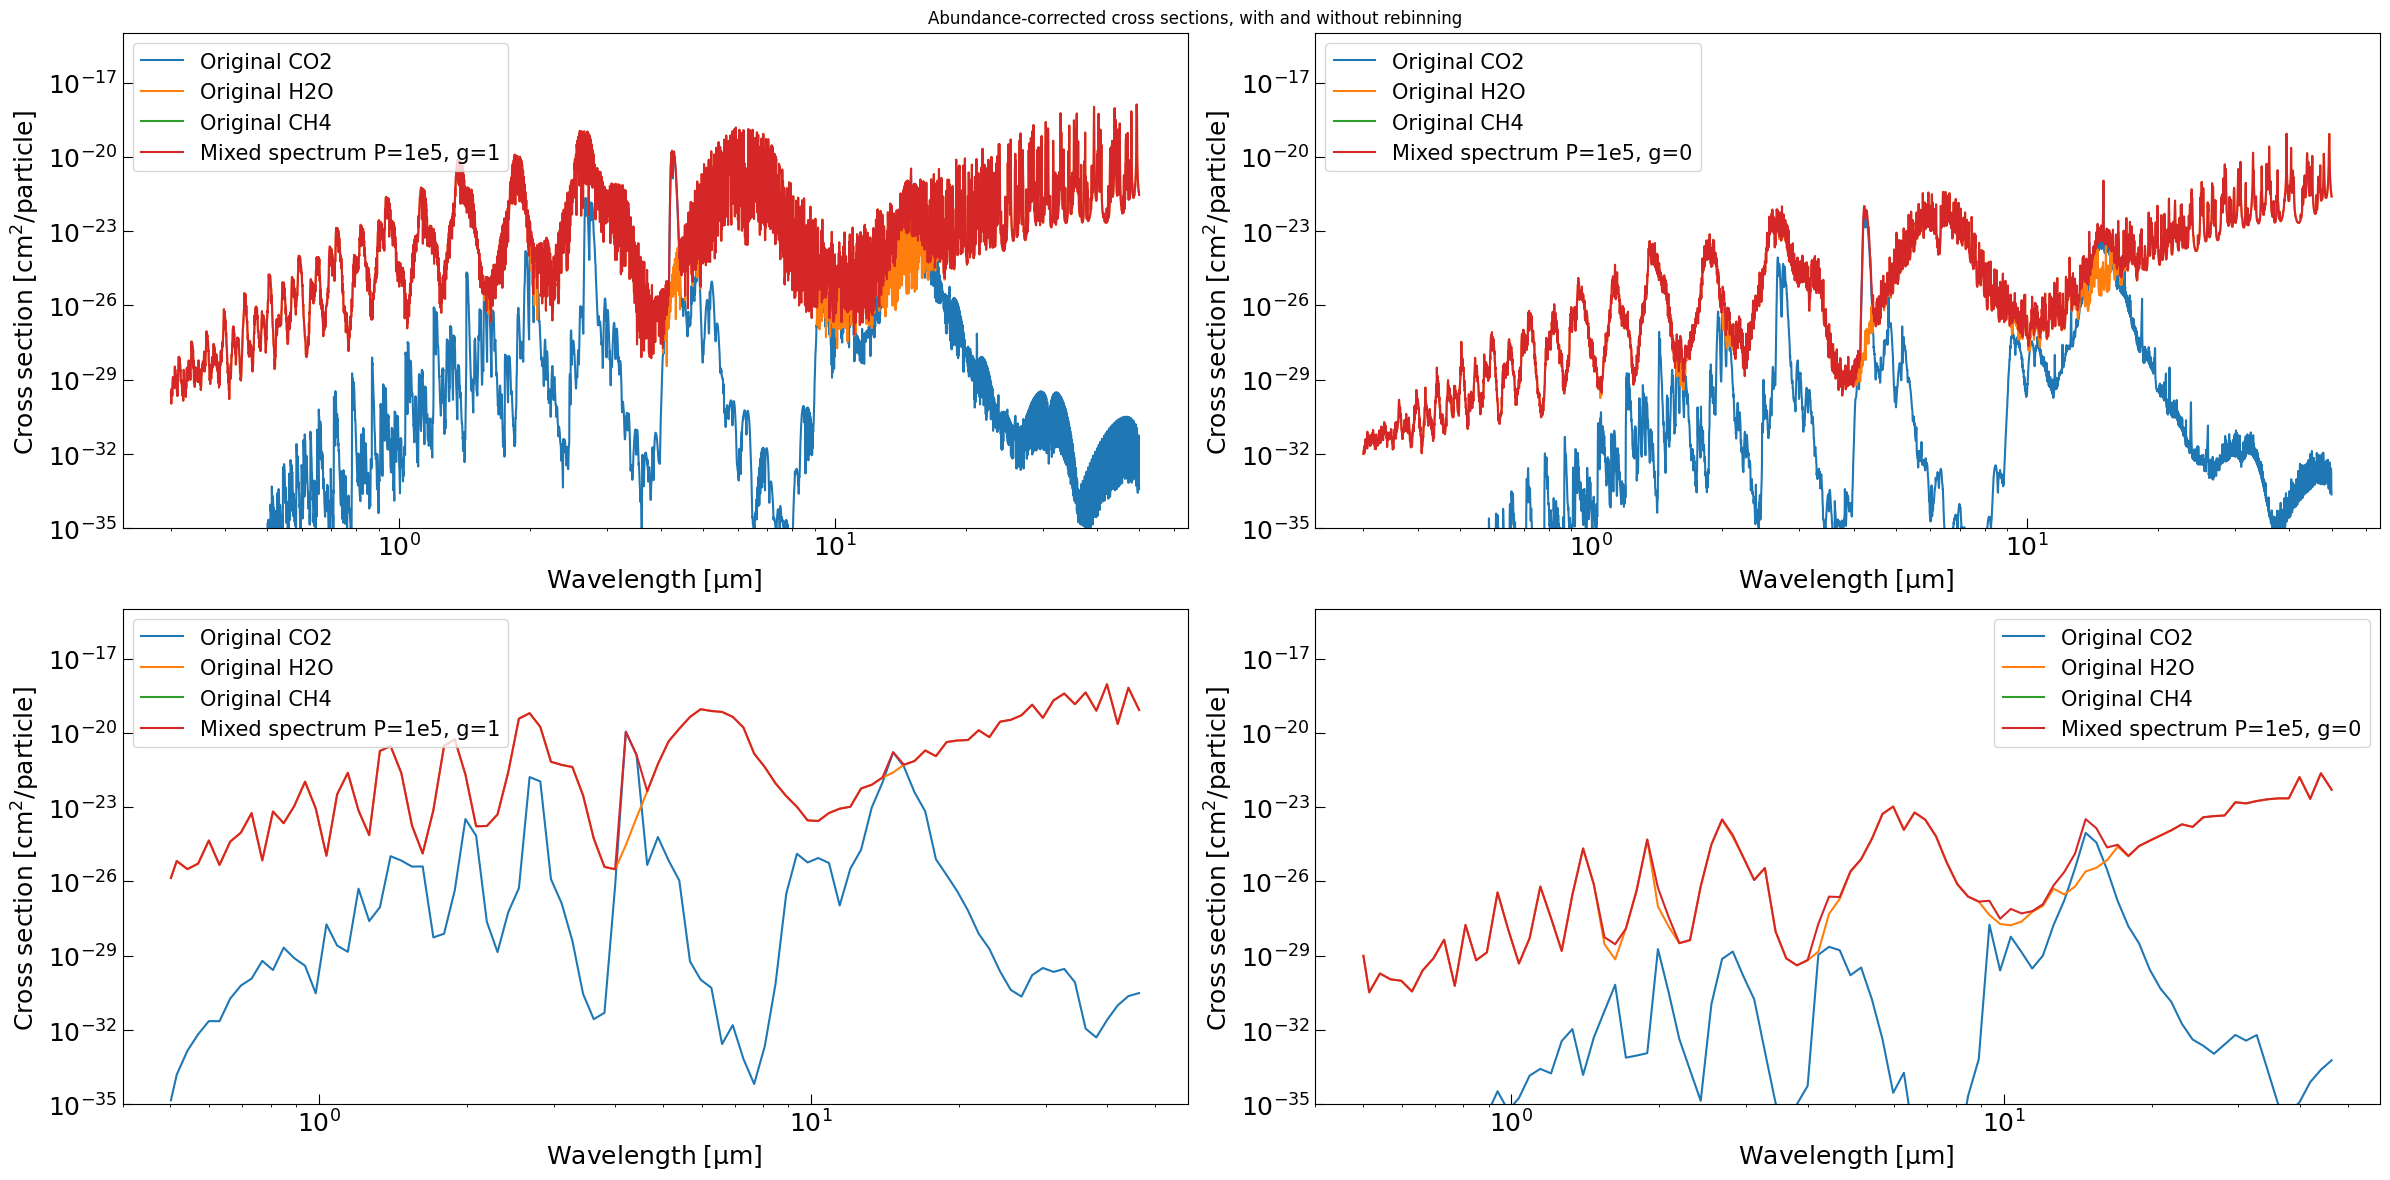

In [66]:
#
# Step 2.2: Plot mixed Ktab and Pure species opacity line lists as sanity check whether overlap calculation went correctly
#

p_plot  = 1.e0
t_plot  = 300.
fig,axs = plt.subplots(2,2,sharex=False,sharey=False,figsize=(24,12))
fig.suptitle("Abundance-corrected cross sections, with and without rebinning")

for s,spc in enumerate(species):
    spc["ktab"].plot_spectrum(axs[0,0],p=p_plot         ,     t=t_plot,g=1.,yscale='log',xscale='log',label='Original '+spc["name"])
    spc["ktab"].plot_spectrum(axs[0,1],p=p_plot         ,     t=t_plot,g=0.,yscale='log',xscale='log',label='Original '+spc["name"])
    
    spc["ktab_rebin"].plot_spectrum(axs[1,0],p=p_plot         ,     t=t_plot,g=1.,yscale='log',xscale='log',label='Original '+spc["name"])
    spc["ktab_rebin"].plot_spectrum(axs[1,1],p=p_plot         ,     t=t_plot,g=0.,yscale='log',xscale='log',label='Original '+spc["name"])

mix_ktab_300ppm.plot_spectrum(axs[0,0],p=p_plot, t=t_plot,g=1.,xscale='log',yscale='log', label='Mixed spectrum P=1e5, g=1')
mix_ktab_300ppm.plot_spectrum(axs[0,1],p=p_plot, t=t_plot,g=0.,xscale='log',yscale='log', label='Mixed spectrum P=1e5, g=0')

mix_ktab_300ppm_rebin.plot_spectrum(axs[1,0],p=p_plot, t=t_plot,g=1.,xscale='log',yscale='log', label='Mixed spectrum P=1e5, g=1')
mix_ktab_300ppm_rebin.plot_spectrum(axs[1,1],p=p_plot, t=t_plot,g=0.,xscale='log',yscale='log', label='Mixed spectrum P=1e5, g=0')

for a,ax in enumerate(axs.flat):
    ax.tick_params(axis="both", which='major', labelsize=18, size=7, direction="in")
    ax.set_xlabel(r"$\rm Wavelength\; [\mu m]$ ", fontsize=18)
    ax.set_ylabel(r"$\rm Cross\; section\; [cm^2/particle]$ ", fontsize=18)
    ax.legend(fontsize=15)
    ax.set_ylim([1e-35,1e-15])

fig.tight_layout()


In [143]:
#
#Step 3: Compute the infrared Rosseland mean opacity from the mix tables
#

Tstar     = 5777.
mmw       = 28. * amu 
surface_T = 278.          #K
surface_p = 1. * bar       #dyne/cm^2
scale_H   = 8.5 *  km         #cm
n_total   = surface_p / (kb * surface_T)

print("density air {:.1e}".format(dens_air) + " number density air {:.1e}".format(n_total))


print("particle masses = " + repr(mmw/amu))

itemp = 2
ipress = 15

k_mixp,k_mixs,k_mixr    = compute_mean_opacities_ktab(mix_ktab_300ppm, ipress, itemp, Tstar)
print(" Mean opacities for 300 ppm Mix = " + repr([k_mixp, k_mixs, k_mixr]))
tau       = scale_H * n_total * k_mixr

k_mixp,k_mixs,k_mixr    = compute_mean_opacities_ktab(mix_ktab_300ppm_rebin, ipress, itemp, Tstar)
print(" Mean rebin opacities for 300 ppm Mix = " + repr([k_mixp, k_mixs, k_mixr]))
tau_rebin = scale_H * n_total * k_mixr


print("IR optical depths of the terrestrial atmosphere with and without rebinning at 300 ppm CO2: "+ repr([tau, tau_rebin]))
print("Difference between the accurate and the fast approach, relative:                           "+ repr(1-tau/tau_rebin))

#print("IR optical depths of the terrestrial atmosphere with 300 amd 600 ppm CO2: "+ repr([tau_300ppm, tau_600ppm]))

density air 1.2e-03 number density air 2.6e+19
particle masses = 28.0
In compute_mean_opacities, tgas/pgas = [300.0, 1.0]
 Mean opacities for 300 ppm Mix = [1.584669357439219e-22, 3.3500559106740185e-24, 8.770703626308297e-28]
In compute_mean_opacities, tgas/pgas = [300.0, 1.0]
 Mean rebin opacities for 300 ppm Mix = [1.3660220607542612e-22, 4.394111511777458e-24, 8.793787042713675e-28]
IR optical depths of the terrestrial atmosphere with and without rebinning at 300 ppm CO2: [0.019423401296666937, 0.01947452130701535]
Difference between the accurate and the fast approach, relative:                           0.0026249687754839046


/tmp/ipykernel_44178/3028324206.py:68: RuntimeWarning: divide by zero encountered in scalar divide
  kadd3 += (1./ktab[ipress,itemp,i,j] if 1./ktab[ipress,itemp,i,j] < 1e60 else 0. ) * gwgt


# Part 2: The need for more line physics: Collision-induced absorption
Now the value of $\tau$ in the above calculation is about a factor of ~100 too small w.r.t. the actual Rosseland mean optical depth in Earth's atmosphere.
What is going on?
Indeed when just adding species' absorption spectra together, we forgot an important effect: Line broadening due to collision-induced absorption (CIA). This is an important effect in all planetary atmospheres rendering otherwise transparent gases opaque at high pressures. Briefly, symmetric molecules like $H_2$ in the gas giants or $N_2$ in Earth's atmosphere do not have a permanent dipole, which gives photons no 'angle of attack' to be absorbed - these gases are therefore transparent. However, once numerous collisions come into play, those can on average, induce a non-zero dipole moment in symmetric molecules, which creates absorption bands and broadens already existing lines in asymmetric molecules.

See https://people.seas.harvard.edu/~rwordsworth/papers/wordsworth2013hydrogen.pdf for more in-depth detail.
Also note that there is a large number of other, similar sounding, but physically distinct broadening mechanisms, explained more in depth in Chapters 13 and 14 in 
https://phys.libretexts.org/Bookshelves/Astronomy__Cosmology/The_Fundamentals_of_Stellar_Astrophysics_(Collins)

We can add the data required for CIA via changing the database code a bit.

In [170]:
#
#Step 1: Build new databases and gas composition object
#

##Path for CIA data
ciapath = '/home/mschulik/petitRadtrans/input_data/opacities/continuum/CIA'
xk.Settings().add_search_path(ciapath, path_type = 'cia')
xk.Settings().set_mks(True)

##Path for corr-k data
datapath = '/home/mschulik/petitRadtrans/input_data/opacities/lines/corr_k/'
database=xk.Kdatabase({'H2O':datapath + 'H2O_Exomol/1H2-16O__POKAZATEL_REDOWNLOAD__R1000_0.3-50mu.ktable.petitRADTRANS.h5',
                       'CO2':datapath + 'CO2/12C-16O2__UCL-4000.R1000_0.3-50mu.ktable.petitRADTRANS.h5', 
                        'CO':datapath + 'CO/C-O-NatAbund__Li2015.R1000_0.3-50mu.ktable.petitRADTRANS.h5'},
                       )

#Loads CIA and sample them on the right spectral grid.
cia_data=xk.CIAdatabase(molecule_pairs=[['H2','H2'],['H2O','H2O'],['N2','H2O']], mks=True)
cia_data.sample(database.wns)

#Gas mix with CIA
gas=xk.Gas_mix(composition={'N2':'background','CO2':340.e-6, 'H2O':0.015},k_database=database, cia_database=cia_data)
print(gas)

#Gas mix without CIA
gas2=xk.Gas_mix(composition={'N2':'background','CO2':340.e-6, 'H2O':0.015},k_database=database)
print(gas2)

#Gas mix for Mars
gas_mars=xk.Gas_mix(composition={'CO2':0.098, 'H2O':0.00},k_database=database, cia_database=cia_data)
print(gas)

print("Cia data")
print(gas.cia_database)
print("k data")
print(gas.k_database)

Volume mixing ratios in Gas_mix: 
CO2->0.00034
H2O->0.015
inactive_gas->0.0
N2->0.98466

Volume mixing ratios in Gas_mix: 
CO2->0.00034
H2O->0.015
inactive_gas->0.0
N2->0.98466

Volume mixing ratios in Gas_mix: 
CO2->0.00034
H2O->0.015
inactive_gas->0.0
N2->0.98466

Cia data
The available molecule pairs are: 
H2-H2->/home/mschulik/petitRadtrans/input_data/opacities/continuum/CIA/H2-H2_2011.hdf5
H2O-H2O->/home/mschulik/petitRadtrans/input_data/opacities/continuum/CIA/H2O-H2O_continuumTurbet_MT_CKD3.3.hdf5
H2O-N2->/home/mschulik/petitRadtrans/input_data/opacities/continuum/CIA/H2O-N2_continuumTurbet_MT_CKD3.3.hdf5
All tables share a common spectral grid

k data
The available molecules are: 
H2O->/home/mschulik/petitRadtrans/input_data/opacities/lines/corr_k/H2O_Exomol/1H2-16O__POKAZATEL_REDOWNLOAD__R1000_0.3-50mu.ktable.petitRADTRANS.h5
CO2->/home/mschulik/petitRadtrans/input_data/opacities/lines/corr_k/CO2/12C-16O2__UCL-4000.R1000_0.3-50mu.ktable.petitRADTRANS.h5
CO->/home/mschulik/peti

Rosseland mean optical depth = 1.6827933020324024
Rosseland mean optical depth = 1.6827933020324024
Rosseland mean optical depth = 0.034931323688871994


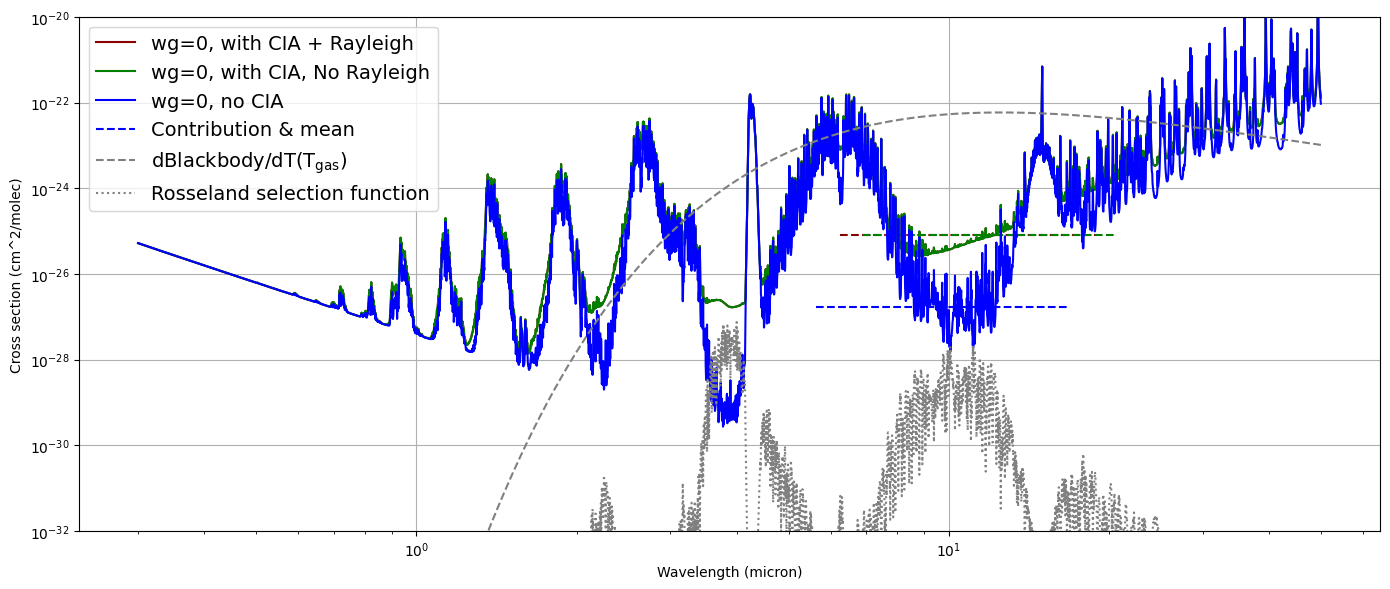

In [171]:
#
# Step 2: Plot the new opacity structures, contribution functions and how those change upon including CIA and Rayleight scattering. 
#         Try also for higher temperatures of exoplanets (setting e.g. t_gas = 1000.), to see when CIA become unimportant.
#
fig,ax=plt.subplots(1,1,sharey=False,figsize=(14,6))
ax.set_ylabel('Cross section (cm^2/molec)')
ax.set_xlabel('Wavelength (micron)')

mks_to_cgs = 1e4

logp_array=5.
t_gas = 300.

scale_H = 8e5
n_total = 2.6e19

labels   = ["wg=0, with CIA + Rayleigh", "wg=0, with CIA, No Rayleigh", "wg=0, no CIA"]
cols = ["darkred", "green", "blue"]
rayleigh = [True, False, False]
gasobjects = [gas, gas, gas2]
offsets    = [1, 1.1, 0.9]  #Slight offsets for sectors of max. contributions

for i in ([0,1,2]):
    kdata = gasobjects[i].cross_section(logp_array=logp_array, t_array=t_gas, rayleigh=True)
    ax.loglog(10000./gasobjects[i].wns, kdata[0,:,0]*mks_to_cgs, label = labels[i], c=cols[i])
    meanopas = compute_mean_opacities_notabs(gasobjects[i], kdata[0], gastemp=t_gas, Tstar=5777 )
    kappa_r  = meanopas[2]
    x,y        = meanopas[3][0], meanopas[3][1]
    x_at_max_y = x[y.argmax()]*offsets[i]
    ax.loglog([x_at_max_y*0.5, x_at_max_y*1.5],[kappa_r, kappa_r], c=cols[i], ls='--', label="Contribution & mean" if i==2 else "")

    tau = scale_H * n_total * kappa_r
    print("Rosseland mean optical depth = " + repr(tau))

ax.loglog(meanopas[3][0], meanopas[3][1]*1e-12, label = r"$\rm dBlackbody/dT(T_{\rm gas})$", c="grey", ls='--')
ax.loglog(meanopas[3][0], meanopas[3][2]*1e-49, label = "Rosseland selection function", c="grey", ls=':')


ax.legend(fontsize=14)
ax.set_ylim([1e-32,1e-20])
ax.grid()
fig.tight_layout()

#
# Now our Rosseland mean should be about ~2, which is close to the real value for Earth
# The coloured, dashed lines in our plot below shows on the x-axis is a visual aid, which shows roughly which range of the absorption spectrum dominates in determining the Rosseland mean. 
# The grey dotted line is a more quantitative variant of this, and the Blackbody differential is the selection function applied to the harmonic mean to calculate the Rosseland mean.
# The y-axis position of the dashed lines is the Rosseland mean.
#

# Part 3: The natural and unnatural Greenhouse effects on planet Earth 

Now everything is in place - we have added add all the physics and we can now study how planetary temperatures respond to different optical depths, 
   due to the presence of an atmosphere and due to changes in said atmosphere's composition (e.g. by exhausting ridiculous amounts of CO2...). We will explore how the temperatures respond to a change from 300ppm to 425ppm atmospheric $CO_2$ content.
 On the implementation side, we use the same gas object now, but merely update its composition,which allows us to faster recalculate the cross sections and optical depths.


In [164]:

s1   = 1.4e6 #solar constant in erg/s/cm^2
kp1  = 1.
kps1 = 1e-2


labels   = ["Earth, no atmosphere", "Earth, 300ppm CO2", "Earth, 425ppm CO2"]
abnds_N2 =  [0, 0.98, 0.98]
abnds_H2O = [0, 0.015, 0.015]
abnds_CO2 = [0, 300*ppm, 425*ppm]

logp_array = 5
t_gas      = 300.

taus    =[]
Temps_G =[]
Temps_M =[]

for i in ([0,1,2]):
    
    gas.set_composition({"N2": abnds_N2[i],"H2O": abnds_H2O[i], "CO2": abnds_CO2[i]})
    
    kdata    = gas.cross_section(logp_array=logp_array, t_array=t_gas, rayleigh=True)
    meanopas = compute_mean_opacities_notabs(gasobjects[i], kdata[0], gastemp=t_gas, Tstar=5777 )
    kappa_r  = meanopas[2]

    tau       = scale_H * n_total * kappa_r
    T_guillot = temperature_guillot(0., s1, kps1, kps1, kp1, kp1, 1./np.sqrt(3.), 1./2., 1./3., tau, Tint=0.)
    T_milne   = temperature_milne(tau, (s1/4/sigma_rad)**0.25) #We can also try to use Milne's solution if we interpret the hemispheric irradiation average as the internal Temperature
    
    print("Optical depth = " + repr(tau) + " Temperatures Guillot/Milne in Celcius = " + repr([T_guillot-273 , T_milne-273 ]))
    taus = np.append(taus,tau)

#
# Exercises:
# 1. What is the predicted global warming from 300ppm to 425ppm CO2 from this, and how does this compare to the true values?
# 2. How does the natural greenhouse effect due to only Water compare to this?
# 3. Compare with #Equilibrium temperature is 278K with 0 albedo and Stratospheric temperature of 220K - why are those colder?
# 4. How does the classical Milne solution stack up against Guillot's values?
#

/tmp/ipykernel_44178/873767155.py:211: RuntimeWarning: divide by zero encountered in scalar divide
  kadd3 += 1./crosssections[i,j] * gwgt
/tmp/ipykernel_44178/873767155.py:212: RuntimeWarning: divide by zero encountered in scalar divide
  selectionfunc[i] += 1./crosssections[i,j] * gwgt


Optical depth = 0.0 Temperatures Guillot/Milne in Celcius = [-67.09835439868212, -37.29773960448418]
Optical depth = 1.6757055193843295 Temperatures Guillot/Milne in Celcius = [7.737602554339219, 49.701168386085726]
Optical depth = 1.6949527723433104 Temperatures Guillot/Milne in Celcius = [8.300418035172356, 50.36204366602152]


# Caveats
What can the above simple calculations capture and not capture? Line-broadening effects are included, so can optionally collision-induced absorptions. The framework fails however to produce more subtle trends of line saturation, as those are only captured in proper line-by-line radiation transport calculations. With this, behaviour of the 'curve of growth' cannot be captured, and the man-made Greenhouse effect is underestimated. Therefore, while we have created a useful tool to understand the principles of the Greenhouse effect, getting to research-level results would require more work.

Curve of growth:
https://en.wikipedia.org/wiki/Curve_of_growth
https://phys.libretexts.org/Bookshelves/Astronomy__Cosmology/The_Fundamentals_of_Stellar_Astrophysics_(Collins)/14%3A_Shape_of_Spectral_Lines/14.06%3A_Curve_of_Growth_of_the_Equivalent_Width

Inconsistencies and feedback effects: For all our calculations we had to input some values of $T_{gas}$ as starting guesses for the temperature - otherwise there would be no spectral line width and blackbody over which to average to begin with. A real world calculation will have to iterated on this process to find whether the new temperatures we calculate are stable or unstable.

# Part 4: The $CO_2$ dominated atmosphere of Mars
Let us now apply our understanding from the case of Earth without atmospehre ($\tau=0$) to that of Mars, which has a $CO_2$ dominated atmosphere, but a very thin one.
In fact, it is so thin, it is optically thin, as it will turn out, explaining how Mars suffers from next to no Greenhouse effect.
Let's do the calculations.

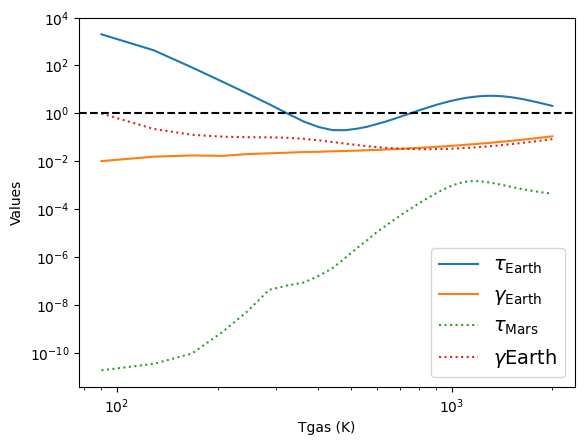

In [169]:

temps   = np.linspace(90, 2000,50)
taus    = 0. * temps
gammas  = 0. * temps

#Earth parameters
for t,temp in enumerate(temps):
    kdata    = gas.cross_section(logp_array=logp_array, t_array=temp, rayleigh=True)
    meanopas = compute_mean_opacities_notabs(gas, kdata[0], gastemp=temp, Tstar=5777 )
    taus[t]  = 8e5 * 2.6e19 * meanopas[2]
    gammas[t]=  meanopas[1]/meanopas[0]

plt.loglog(temps, taus, label=r'$\tau_{\rm Earth}$')
plt.loglog(temps, gammas,label=r'$\gamma_{\rm Earth}$')

#Mars parameters
for t,temp in enumerate(temps):
    kdata    = gas_mars.cross_section(logp_array=logp_array, t_array=temp, rayleigh=True)
    meanopas = compute_mean_opacities_notabs(gas_mars, kdata[0], gastemp=temp, Tstar=5777 )
    taus[t]  = 11e5 * 2.6e17 * meanopas[2]
    gammas[t]=  meanopas[1]/meanopas[0]

#Plot optical depths and heating gammas
plt.loglog(temps, taus, label=r'$\tau_{\rm Mars}$', ls=':')
plt.loglog(temps, gammas,label=r'$\gamma{\rm Earth}$', ls=':')
plt.axhline(y=1.0,c='k',ls='--')
plt.ylabel('Values')
plt.xlabel('Tgas (K)')

plt.legend(fontsize=14)

# Part 5: Alien worlds
Now we repeat this process in a way that lets us explore different chemical compositions, using the binned-down k-tables.
We will move away from Earth's case to explore the compositions of plausible Alien worlds and assess their temperatures.

Our main tool which we change is the composition dictionary/array, everything else remains the same. We now update our understanding of $\tau$ as a multidimensional function: In principle, each abundance for species s in the atmosphere is an independent number, given by the number density $n_s$ or the number fraction $f_s = n_s / n_{\rm total}$. So numerating all species from $s_0$ to $s_{N-1}$, when there are a total of N species, $\tau$ depends on a N-dimensional vector of all species densities $\{n_s\}$. For example in an atmosphere composed of $\rm N_2$, $\rm H_2O$ and $\rm CO_2$, $\tau(f_{\rm N_2}, f_{\rm H_2O}, f_{\rm CO_2})$ depends on three axes.

A base code then needs to loop over 3 different compositions and redo the computations from Part 1 for each of the points in this 3 dimensional space, in order to understand what values $\tau$ can obtain. Extending the compositional space now to plausible alien worlds would mean to extend the number of possible species to a e.g. N dimensional $\tau(f_{\rm s_0},..., f_{\rm s_{N-1}})$.

In order to explore what temperatures are plausible (given the same planetary scale heights, atmospheric pressure), we will use $N=10$. This will generate a large amount of data, and take many evaluations of the k-overlap routine, so we need to make sure to be computationally optimal. Computing even only 3 points along each composition axis requires $3^{10} = 59049$ calculations.


In [156]:
# This only shows the general logic in a 2-dimensional space

#Step 0:
#To write: Combinatorial routine to reevaluate the abundance dictionary
#          Create new, extended species dictionary
Tplanet = 0
s1   = 1.4e6 #solar constant in erg/s/cm^2
kp1  = 1.
kps1 = 1e-2

ppm=1e-6
logp_array = 5
temp = 300
scale_H = 8e5
n_total = 2.6e19

abnds_H2O = [1e0, 1e-2, 4e-2]
abnds_CO2 = [300*ppm, 600*ppm, 900*ppm]

#Step 1:
#For all compositions do...
#TODO: Optimization: each overlap calculations does overlaps the entire composition at each P and T in the ktab files. Preselect those and then overlap, this should speed us up a lot.

for a1 in abnds_H2O:
    for a2 in abnds_CO2:

        #Set new abundances
        gas.set_composition({"N2": 1.,"H2O": a1, "CO2": a2, "CH4": 0.})
        
        kdata    = gas.cross_section(logp_array=logp_array, t_array=temp, rayleigh=True)
        meanopas = compute_mean_opacities_notabs(gas, kdata[0], gastemp=temp, Tstar=5777 )
        k_mixr    = meanopas[2]
        #Optical depth
        tau_rebin            = scale_H * n_total * k_mixr
        
        #Surface temperature
        T_rebin       = temperature_guillot(0., s1, kps1, kps1, kp1, kp1, 1./np.sqrt(3.), 1./2., 1./3., tau_rebin, Tplanet)
        
        print("Result = "+ repr([a1, a2, k_mixr, tau_rebin, T_rebin]))
        #Save to file
        

Result = [1.0, 0.0003, 2.199524344831127e-22, 4575.010637248744, 628.5687209545706]
Result = [1.0, 0.0006, 2.213691622297818e-22, 4604.478574379461, 628.5687209545706]
Result = [1.0, 0.0009, 2.2216005726510126e-22, 4620.929191114106, 628.5687209545706]
Result = [0.01, 0.0003, 4.005981510837554e-26, 0.8332441542542112, 251.6179041394789]
Result = [0.01, 0.0006, 4.147803657786881e-26, 0.8627431608196712, 252.82837276731854]
Result = [0.01, 0.0009, 4.2558849164006663e-26, 0.8852240626113386, 253.73891232101494]
Result = [0.04, 0.0003, 4.722393637374529e-25, 9.822578765739019, 401.31365028050396]
Result = [0.04, 0.0006, 4.7814321812261025e-25, 9.945378936950293, 402.3791442007938]
Result = [0.04, 0.0009, 4.822801857616296e-25, 10.031427863841897, 403.1194109483004]
